In [117]:
# import important libraries

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

In [118]:
#  load data

df1 = pd.read_csv('data/coin_gecko_2022-03-16.csv')
df2 = pd.read_csv('data/coin_gecko_2022-03-17.csv')

In [119]:
df1.head()

,coin,symbol,price,1h,24h,7d,24h_volume,mkt_cap,date
0,Bitcoin,BTC,40859.460000,0.022,0.030,0.055,3.539076e+10,7.709915e+11,2022-03-16
1,Ethereum,ETH,2744.410000,0.024,0.034,0.065,1.974870e+10,3.271044e+11,2022-03-16
2,Tether,USDT,1.000000,-0.001,-0.001,0.000,5.793497e+10,7.996516e+10,2022-03-16
3,BNB,BNB,383.430000,0.018,0.028,0.004,1.395854e+09,6.404382e+10,2022-03-16
4,USD Coin,USDC,0.999874,-0.001,0.000,-0.000,3.872274e+09,5.222214e+10,2022-03-16


In [120]:
df2.head()

,coin,symbol,price,1h,24h,7d,24h_volume,mkt_cap,date
0,Bitcoin,BTC,40851.380000,0.001,0.000,-0.027,2.047612e+10,7.760774e+11,2022-03-17
1,Ethereum,ETH,2824.420000,0.004,0.029,0.034,1.364041e+10,3.390772e+11,2022-03-17
2,Tether,USDT,1.000000,-0.000,0.000,0.000,4.413140e+10,8.020588e+10,2022-03-17
3,BNB,BNB,389.610000,0.002,0.016,-0.010,1.425354e+09,6.556116e+10,2022-03-17
4,USD Coin,USDC,0.999739,-0.001,0.000,-0.000,3.569816e+09,5.259607e+10,2022-03-17


In [121]:
# join the data

df = pd.concat([df1 , df2] , axis=0)

In [122]:
df

,coin,symbol,price,1h,24h,7d,24h_volume,mkt_cap,date
0,Bitcoin,BTC,40859.460000,0.022,0.030,0.055,3.539076e+10,7.709915e+11,2022-03-16
1,Ethereum,ETH,2744.410000,0.024,0.034,0.065,1.974870e+10,3.271044e+11,2022-03-16
2,Tether,USDT,1.000000,-0.001,-0.001,0.000,5.793497e+10,7.996516e+10,2022-03-16
3,BNB,BNB,383.430000,0.018,0.028,0.004,1.395854e+09,6.404382e+10,2022-03-16
4,USD Coin,USDC,0.999874,-0.001,0.000,-0.000,3.872274e+09,5.222214e+10,2022-03-16
...,...,...,...,...,...,...,...,...,...
495,IRISnet,IRIS,0.055426,0.016,-0.003,-0.088,2.976839e+06,6.809024e+07,2022-03-17
496,Circuits of Value,COVAL,0.037961,0.002,-0.012,-0.054,3.667870e+05,6.782627e+07,2022-03-17
497,ARPA Chain,ARPA,0.069003,-0.000,0.008,-0.037,1.363376e+07,6.776284e+07,2022-03-17
498,SuperRare,RARE,0.464613,-0.003,0.014,0.019,9.398219e+06,6.738822e+07,2022-03-17


In [123]:
df.info()

<class 'pandas.DataFrame'>
Index: 1000 entries, 0 to 499
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   coin        1000 non-null   str    
 1   symbol      1000 non-null   str    
 2   price       1000 non-null   float64
 3   1h          993 non-null    float64
 4   24h         993 non-null    float64
 5   7d          992 non-null    float64
 6   24h_volume  993 non-null    float64
 7   mkt_cap     1000 non-null   float64
 8   date        1000 non-null   str    
dtypes: float64(6), str(3)
memory usage: 100.4 KB


In [124]:
df.describe()

,price,1h,24h,7d,24h_volume,mkt_cap
count,1.000000e+03,993.000000,993.000000,992.000000,9.930000e+02,1.000000e+03
mean,6.561060e+02,0.009723,0.023737,0.023558,2.893109e+08,3.755304e+09
std,4.584655e+03,0.026934,0.059303,0.229781,2.769908e+09,3.803783e+10
min,1.484000e-09,-0.704000,-0.646000,-0.558000,0.000000e+00,6.577043e+07
25%,1.940547e-01,0.001000,0.001000,-0.041000,1.766976e+06,1.157776e+08
50%,1.095000e+00,0.006000,0.016000,-0.000500,8.343005e+06,2.120036e+08
75%,7.232500e+00,0.019000,0.035000,0.037000,4.003652e+07,5.948436e+08
max,4.121727e+04,0.095000,0.577000,4.608000,5.793497e+10,7.760774e+11


In [125]:
df.duplicated().sum()

np.int64(0)

## Drop columns

we have seen in the EDA date has no variance , coin and  symbol not provide any inforemation we can drop

In [126]:
df.drop(['date' , 'coin' , 'symbol'] , axis=1 , inplace=True) 

In [127]:
df.head()

,price,1h,24h,7d,24h_volume,mkt_cap
0,40859.460000,0.022,0.030,0.055,3.539076e+10,7.709915e+11
1,2744.410000,0.024,0.034,0.065,1.974870e+10,3.271044e+11
2,1.000000,-0.001,-0.001,0.000,5.793497e+10,7.996516e+10
3,383.430000,0.018,0.028,0.004,1.395854e+09,6.404382e+10
4,0.999874,-0.001,0.000,-0.000,3.872274e+09,5.222214e+10


## outlier treatment

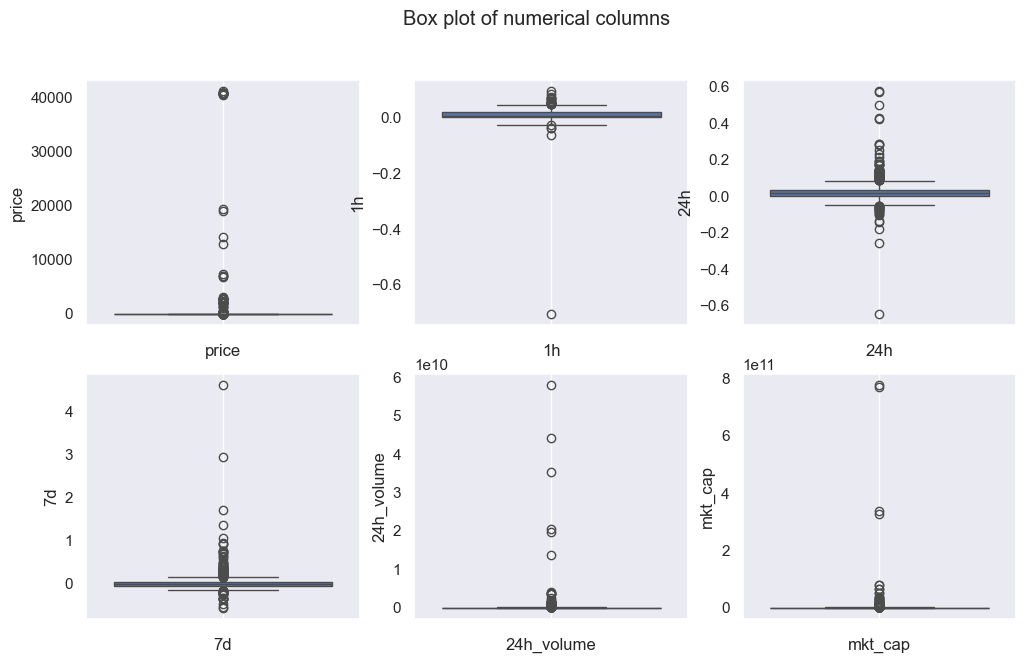

In [128]:
# check the outliers 

plt.figure(figsize=(12 , 7))
plt.suptitle('Box plot of numerical columns')

columns = ['price' , '1h' , '24h', '7d' , '24h_volume' , 'mkt_cap']

for i in range(0 , len(df.columns)):
    plt.subplot(2 , 3 , i+1)
    sns.boxplot(df[columns[i]])
    plt.xlabel(columns[i])
    plt.grid()
plt.show()

In [129]:
def outlier_handle(columns):

    for column in columns:
        
        q1 = df[column].quantile(0.25)
        q3 = df[column].quantile(0.75)

        iqr = q3-q1

        upper_limit = q3 + iqr*1.5
        lower_limit = q1 - iqr*1.5
        df.loc[(df[column]>upper_limit), column]= upper_limit
        df.loc[(df[column]<lower_limit), column]= lower_limit

    plt.figure(figsize=(12 , 7))
    plt.suptitle('Box plot of numerical columns')

    for i in range(0 , len(columns)):
        plt.subplot(2 , 3 , i+1)
        sns.boxplot(df[columns[i]])
        plt.xlabel(columns[i])
        plt.grid()
    plt.show()

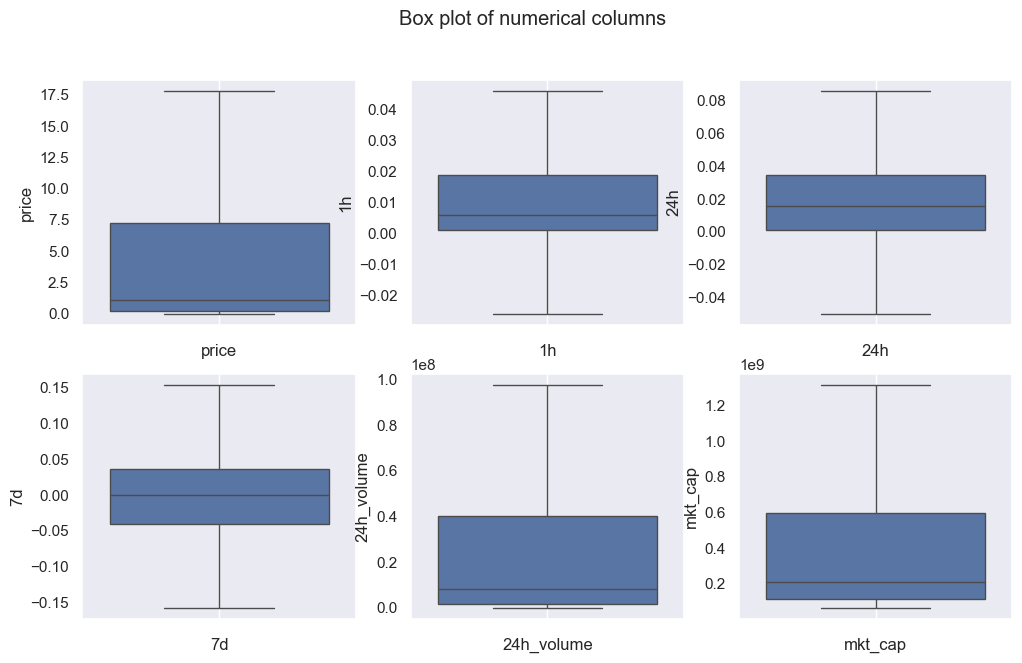

In [130]:
columns = ['price' , '1h' , '24h', '7d' , '24h_volume' , 'mkt_cap']

outlier_handle(columns)

## null valuse 

In [131]:
df.isnull().sum()

price         0
1h            7
24h           7
7d            8
24h_volume    7
mkt_cap       0
dtype: int64

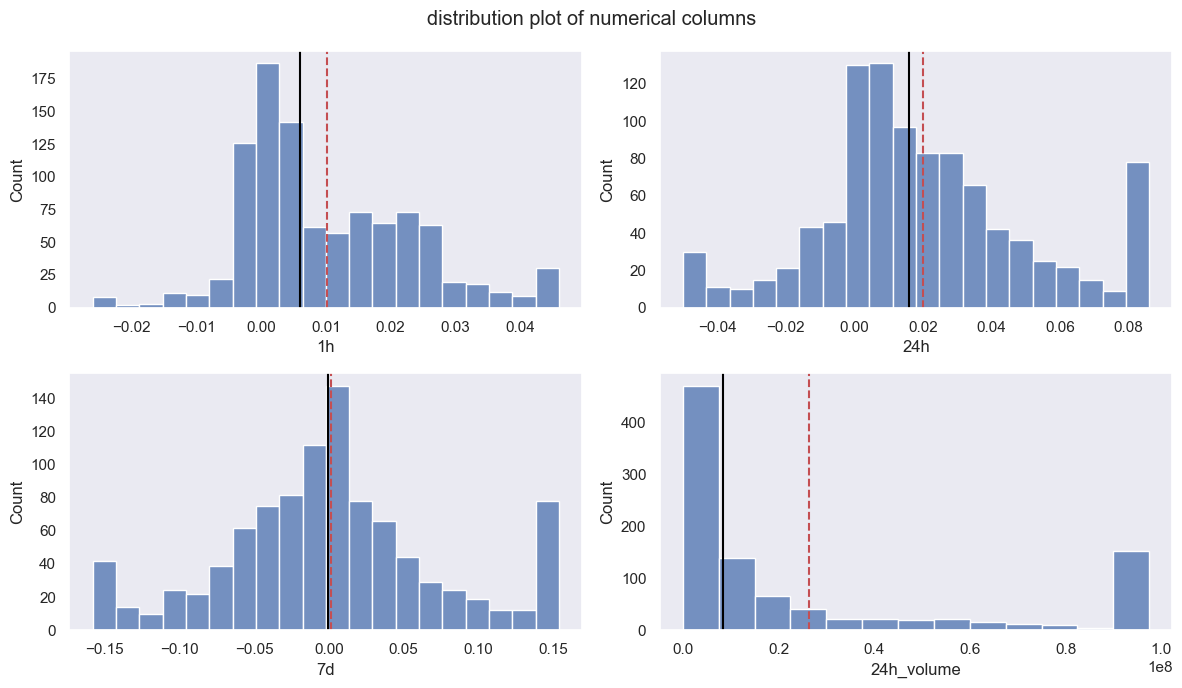

In [132]:
null_col = ['1h' , '24h' , '7d' , '24h_volume']

plt.figure(figsize=(12 , 7))
plt.suptitle('distribution plot of numerical columns')

for i in range(0 , len(null_col)):
    plt.subplot(2 , 2 , i+1)
    sns.histplot(df[null_col[i]])
    plt.axvline(df[null_col[i]].mean() , color='r' , linestyle='--')
    plt.axvline(df[null_col[i]].median() , color='black')
    plt.xlabel(null_col[i])
    plt.grid()
plt.tight_layout()
plt.show()

In [133]:
# fill num value
for i in null_col:
    df[i] = df[i].fillna(df[i].mean())

In [134]:
# now check the null values
df.isnull().sum()

price         0
1h            0
24h           0
7d            0
24h_volume    0
mkt_cap       0
dtype: int64

## PCA
here the size of data is very small no need of pca

## correlation check

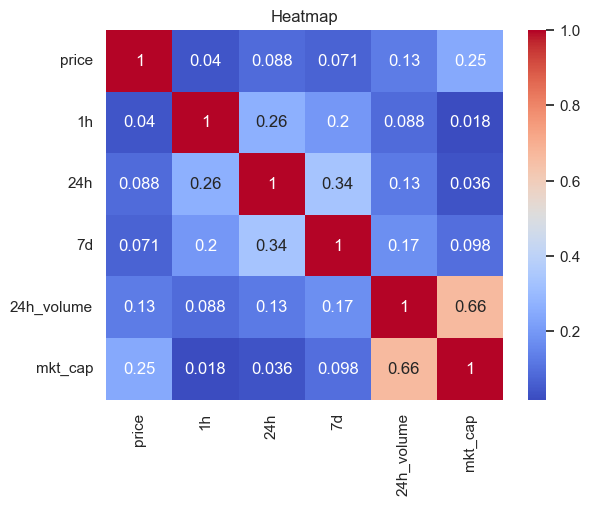

In [135]:
sns.heatmap(df.corr() , cmap='coolwarm' , annot=True)
plt.title('Heatmap')
# plt.grid()
plt.show()

no highly correlation present correlation value should be in the range of (7 to -7)

In [136]:
# creat a new feature liquidity
df['liquidity'] = df['24h_volume'] / df['mkt_cap']
df['liquidity']

0      0.074187
1      0.074187
2      0.074187
3      0.074187
4      0.074187
         ...   
495    0.043719
496    0.005408
497    0.201198
498    0.139464
499    0.000301
Name: liquidity, Length: 1000, dtype: float64

## Liquidity - 
                liqudity means how easily a cryptocurrency can be bought or sold without affecting its price

In [137]:
df.head()

,price,1h,24h,7d,24h_volume,mkt_cap,liquidity
0,17.790168,0.022,0.030,0.055,97440846.0,1.313443e+09,0.074187
1,17.790168,0.024,0.034,0.065,97440846.0,1.313443e+09,0.074187
2,1.000000,-0.001,-0.001,0.000,97440846.0,1.313443e+09,0.074187
3,17.790168,0.018,0.028,0.004,97440846.0,1.313443e+09,0.074187
4,0.999874,-0.001,0.000,-0.000,97440846.0,1.313443e+09,0.074187


In [138]:
# seprate x and y for clustring

x = df.drop(['liquidity'] , axis=1)
y = df['liquidity']

In [139]:
x

,price,1h,24h,7d,24h_volume,mkt_cap
0,17.790168,0.022,0.030,0.055,97440846.00,1.313443e+09
1,17.790168,0.024,0.034,0.065,97440846.00,1.313443e+09
2,1.000000,-0.001,-0.001,0.000,97440846.00,1.313443e+09
3,17.790168,0.018,0.028,0.004,97440846.00,1.313443e+09
4,0.999874,-0.001,0.000,-0.000,97440846.00,1.313443e+09
...,...,...,...,...,...,...
495,0.055426,0.016,-0.003,-0.088,2976839.00,6.809024e+07
496,0.037961,0.002,-0.012,-0.054,366787.00,6.782627e+07
497,0.069003,-0.000,0.008,-0.037,13633759.00,6.776284e+07
498,0.464613,-0.003,0.014,0.019,9398219.00,6.738822e+07


## kmeans clustring

In [140]:

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

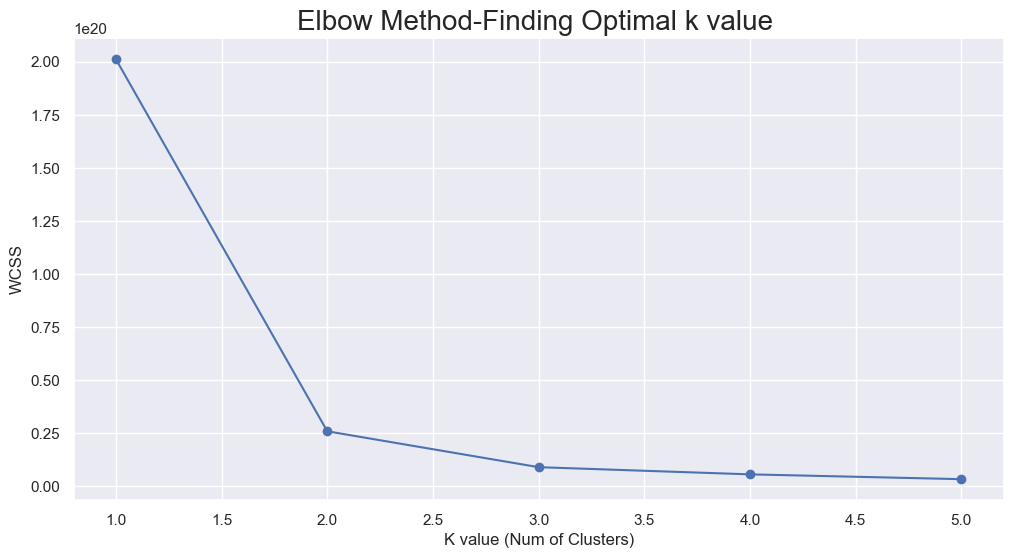

In [141]:
# to find how many cluster should be here

wcss= {}
sns.set()
plt.figure(figsize=(12,6))
for i in range(1,6): 
    km = KMeans(n_clusters=i)
    km.fit(x)
    wcss[i]=km.inertia_

plt.plot(range(1,6),wcss.values(), marker='o')
plt.title('Elbow Method-Finding Optimal k value ', fontsize =20)
plt.xlabel('K value (Num of Clusters)')
plt.ylabel('WCSS')
plt.show()

graph shown the optimal value of cluster it should be 2

In [142]:
km = KMeans(n_clusters=3)
km.fit_transform(x)
pred = km.fit_predict(x)
silhouette_score(x , pred)

0.7428355667152359

## DBSCAN

In [143]:
from sklearn.cluster import DBSCAN

db = DBSCAN(eps=0.2)
pred = db.fit_predict(x)
silhouette_score(x , pred)

0.4971064958175274

KMEANS clustring given more silhouette score than DBSCAN go with kmeans

In [144]:
km = KMeans(n_clusters=3)
km.fit_transform(x)
df['cluster'] = km.labels_

In [145]:
df.head()

,price,1h,24h,7d,24h_volume,mkt_cap,liquidity,cluster
0,17.790168,0.022,0.030,0.055,97440846.0,1.313443e+09,0.074187,2
1,17.790168,0.024,0.034,0.065,97440846.0,1.313443e+09,0.074187,2
2,1.000000,-0.001,-0.001,0.000,97440846.0,1.313443e+09,0.074187,2
3,17.790168,0.018,0.028,0.004,97440846.0,1.313443e+09,0.074187,2
4,0.999874,-0.001,0.000,-0.000,97440846.0,1.313443e+09,0.074187,2


In [146]:
df['cluster'].value_counts()

cluster
1    657
2    194
0    149
Name: count, dtype: int64

In [147]:
df.groupby('cluster')['liquidity'].mean()

cluster
0    0.054498
1    0.080958
2    0.054221
Name: liquidity, dtype: float64

In [148]:
df['liquidity'] = df['cluster'].map({
    0 : 'high',
    1:  'low',
    2 : 'high'
})

In [149]:
df['liquidity'].value_counts()

liquidity
low     657
high    343
Name: count, dtype: int64

In [150]:
df.drop('cluster' , axis=1 , inplace=True)

In [151]:
df.head()

,price,1h,24h,7d,24h_volume,mkt_cap,liquidity
0,17.790168,0.022,0.030,0.055,97440846.0,1.313443e+09,high
1,17.790168,0.024,0.034,0.065,97440846.0,1.313443e+09,high
2,1.000000,-0.001,-0.001,0.000,97440846.0,1.313443e+09,high
3,17.790168,0.018,0.028,0.004,97440846.0,1.313443e+09,high
4,0.999874,-0.001,0.000,-0.000,97440846.0,1.313443e+09,high


save the new data into the file

In [153]:
import os

os.makedirs('data2' , exist_ok=True)
df.to_csv('data2/coin_data.csv' , index=False)